# Anime Image Pipeline Proposal

Proposed pipeline for domain B (anime) preprocessing:
1. Resize to 512×512
2. Crop 256×256 centred at image centre + offset **(0, −14)** px  
   → crop window: x ∈ [128, 384], y ∈ [114, 370]
3. Resize to 128×128 (final model input)

This notebook shows each stage and compares with the current `_anime_crop` approach.

In [1]:
import sys

sys.path.insert(0, "..")

import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

from kaoanime.config import DataConfig
from kaoanime.utils.dataset import _anime_crop
from kaoanime.utils.align import _CELEBA_REF_128

SEED = 42
N_SHOW = 8
FINAL_SIZE = 128

cfg = DataConfig()
rng = random.Random(SEED)

exts = {".jpg", ".jpeg", ".png"}
all_b = [p for p in Path(cfg.root_b).iterdir() if p.suffix.lower() in exts]
sample_paths = rng.sample(all_b, N_SHOW)
print(f"Sampled {N_SHOW} images from {cfg.root_b}")

Sampled 8 images from /beta/home/madorskii/datasets/alignedanimefaces/safebooru_jpeg


## Helper: proposed pipeline

In [42]:
def proposed_pipeline(path: Path, offset_x: int = 0, offset_y: int = -7) -> dict:
    """Return dict with each stage as a PIL image."""
    orig = Image.open(path).convert("RGB")

    # Stage 1: resize to 512×512
    s512 = orig.resize((512, 512), Image.LANCZOS)

    # Stage 2: 256×256 crop — centre at (256 + offset_x, 256 + offset_y)
    cx = 512 // 2 + offset_x  # 256
    cy = 512 // 2 + offset_y  # 242
    half = 256 // 2  # 128
    x0, y0 = cx - half, cy - half
    x1, y1 = cx + half, cy + half
    cropped = s512.crop((x0, y0, x1, y1))

    # Stage 3: resize to 128×128
    final = cropped.resize((FINAL_SIZE, FINAL_SIZE), Image.LANCZOS)

    return dict(
        orig=orig, s512=s512, cropped=cropped, final=final, crop_box=(x0, y0, x1, y1)
    )


def current_pipeline(path: Path) -> Image.Image:
    """Current _anime_crop → resize to 128×128."""
    img = Image.open(path).convert("RGB")
    cropped = _anime_crop(img, 2, cfg.anime_shift_x, cfg.anime_shift_y)
    return cropped.resize((FINAL_SIZE, FINAL_SIZE), Image.LANCZOS)

## Section 1 — Step-by-step for first 4 images

Columns: **Original** | **512×512** | **256×256 crop (box shown)** | **128×128 final**

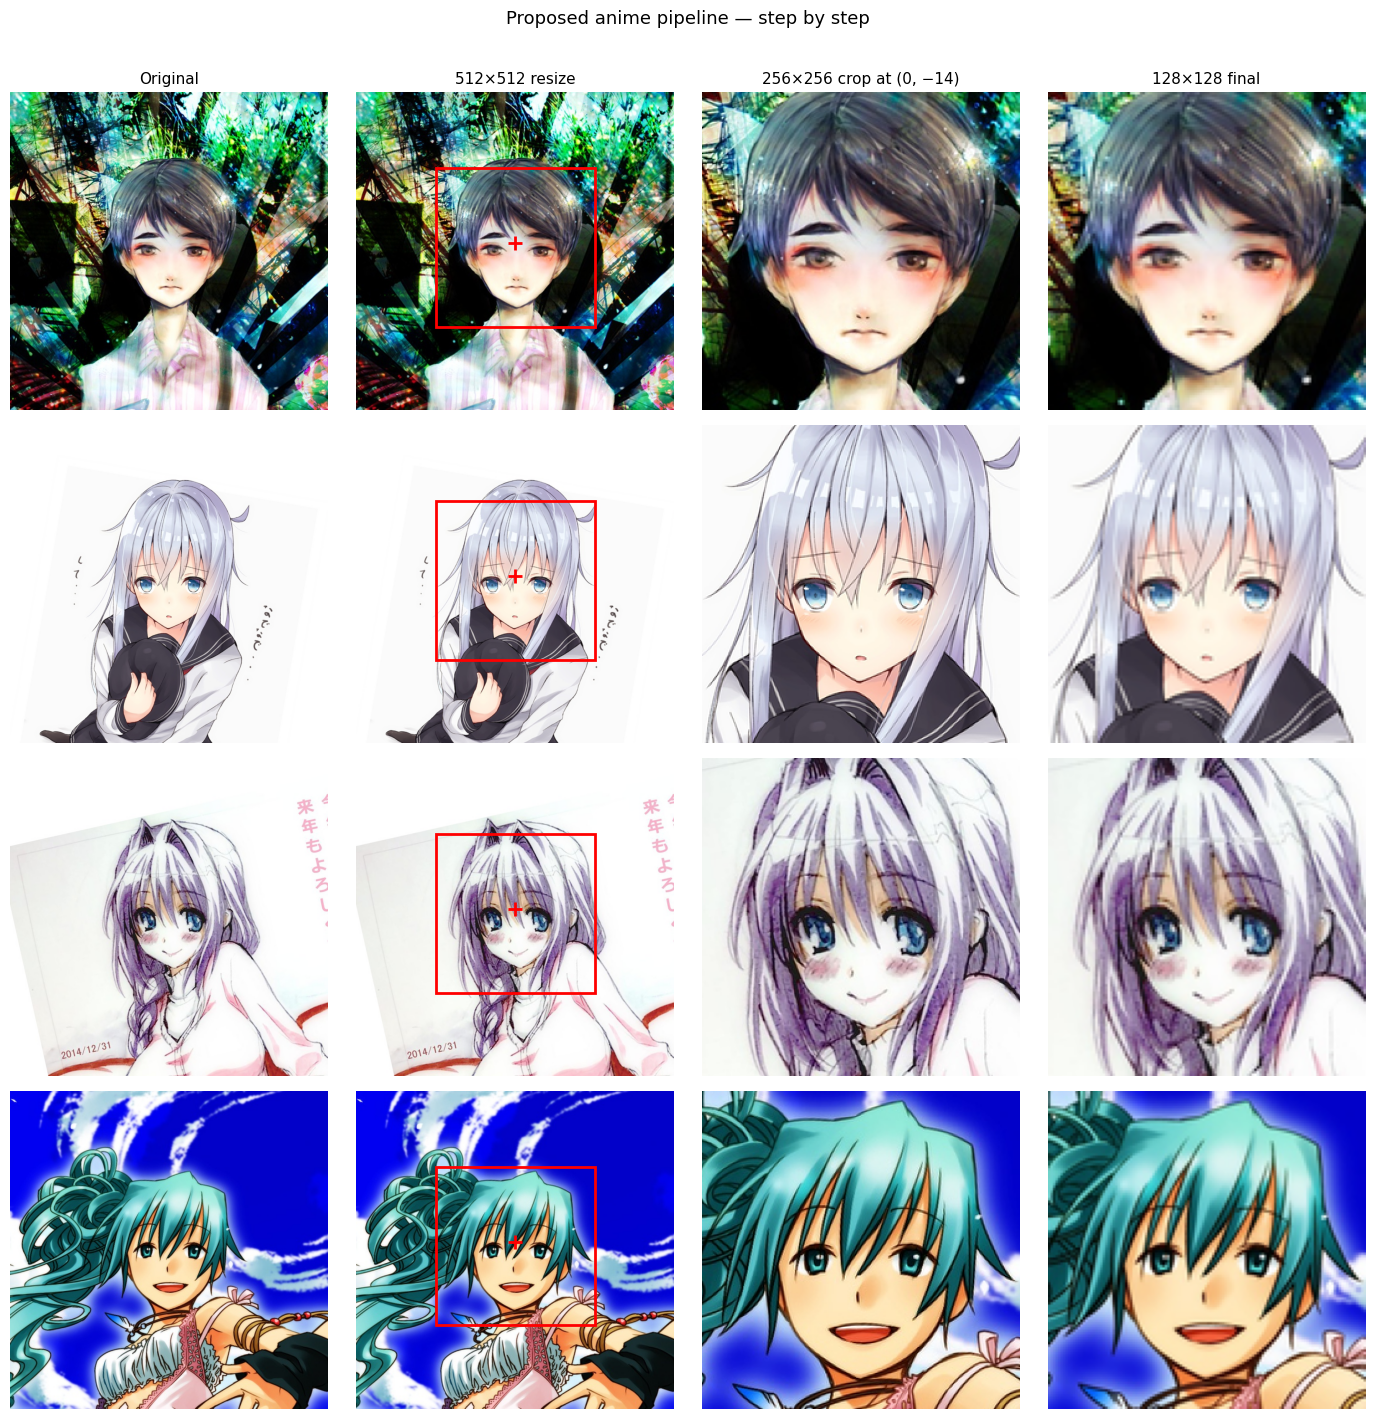

In [43]:
n_detail = 4
fig, axes = plt.subplots(n_detail, 4, figsize=(14, n_detail * 3.5))
col_titles = ["Original", "512×512 resize", "256×256 crop at (0, −14)", "128×128 final"]
for col, t in enumerate(col_titles):
    axes[0, col].set_title(t, fontsize=11)

for row, path in enumerate(sample_paths[:n_detail]):
    stages = proposed_pipeline(path)
    x0, y0, x1, y1 = stages["crop_box"]

    axes[row, 0].imshow(stages["orig"])
    axes[row, 0].axis("off")

    axes[row, 1].imshow(stages["s512"])
    # Draw crop rectangle on 512 image
    rect = mpatches.Rectangle(
        (x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor="red", facecolor="none"
    )
    axes[row, 1].add_patch(rect)
    axes[row, 1].plot(512 // 2, 512 // 2 - 14, "r+", markersize=10, markeredgewidth=2)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(stages["cropped"])
    axes[row, 2].axis("off")

    axes[row, 3].imshow(stages["final"])
    axes[row, 3].axis("off")

fig.suptitle("Proposed anime pipeline — step by step", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Section 2 — Final 128×128 grid (all 8 samples)

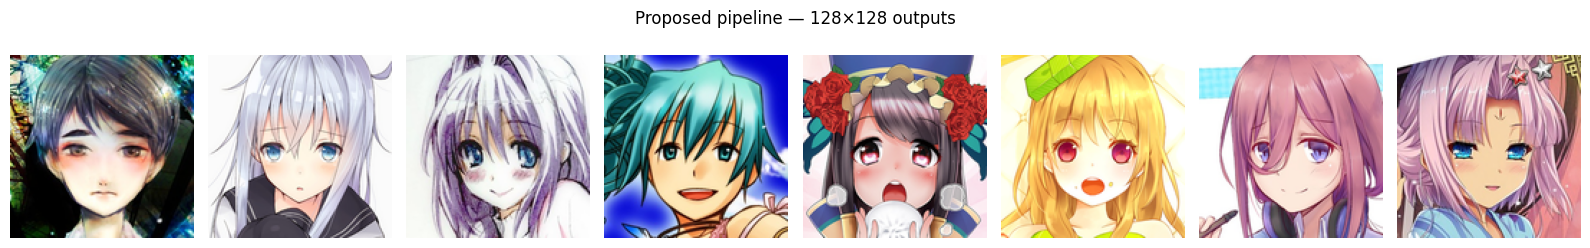

In [44]:
finals = [proposed_pipeline(p)["final"] for p in sample_paths]

fig, axes = plt.subplots(1, N_SHOW, figsize=(N_SHOW * 2, 2.5))
fig.suptitle("Proposed pipeline — 128×128 outputs", fontsize=12)
for ax, img in zip(axes, finals):
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Section 3 — Comparison: proposed vs current

Row 1: proposed pipeline (resize→512, crop 256 at (0,−14), resize→128)  
Row 2: current pipeline (`_anime_crop` scale=1.85, shift_y=−0.01, resize→128)

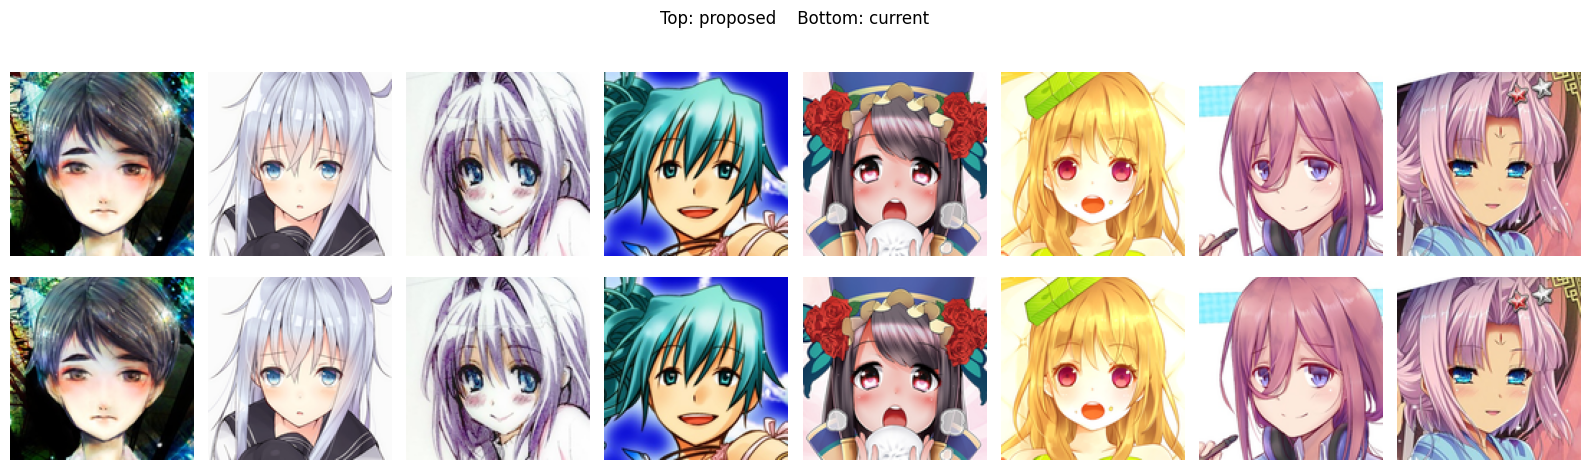

In [45]:
fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2, 5))
fig.suptitle("Top: proposed    Bottom: current", fontsize=12)

for col, path in enumerate(sample_paths):
    axes[0, col].imshow(proposed_pipeline(path)["final"])
    axes[0, col].axis("off")
    axes[1, col].imshow(current_pipeline(path))
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

## Section 4 — Alignment check

Overlay CelebA canonical landmark positions (×) on proposed outputs.  
These are the same crosses shown in `04_data_pipeline.ipynb` — use them to judge whether the crop framing aligns faces with domain A.

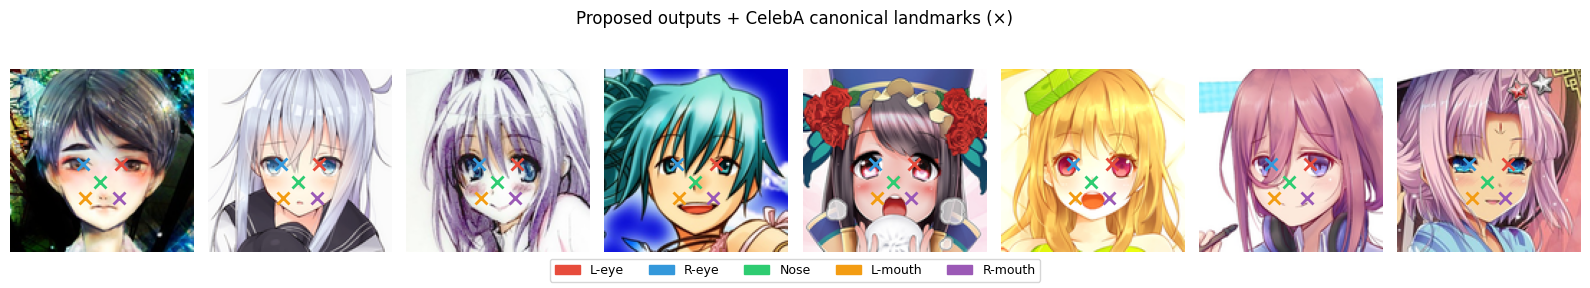

In [46]:
COLORS = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]
LABELS = ["L-eye", "R-eye", "Nose", "L-mouth", "R-mouth"]
canonical = _CELEBA_REF_128

fig, axes = plt.subplots(1, N_SHOW, figsize=(N_SHOW * 2, 2.8))
fig.suptitle("Proposed outputs + CelebA canonical landmarks (×)", fontsize=12)

for ax, img in zip(axes, finals):
    ax.imshow(img)
    for (x, y), c in zip(canonical, COLORS):
        ax.plot(x, y, "x", color=c, markersize=8, markeredgewidth=2)
    ax.axis("off")

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
fig.legend(handles=patches, loc="lower center", ncol=5, fontsize=9)
plt.tight_layout()
plt.show()